In [ ]:

from google.colab import drive
drive.mount('/content/drive')




MessageError: Error: credential propagation was unsuccessful

In [ ]:
import os
from PIL import Image, ImageEnhance #image brightness,sharpness perform kr skte
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Flatten, Dropout
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import VGG16
import numpy as np


In [ ]:
import os
train_dir='/content/drive/MyDrive/Data for Models/Brain_Tumor/Training'
test_dir='/content/drive/MyDrive/Data for Models/Brain_Tumor/Testing'
for label in ["glioma","meningioma","notumor","pituitary"]:
 print(label, "Train_Images:", len(os.listdir(os.path.join(train_dir,label)))) #os.listdir folder ke andar sab files aur folders ki list return karta hai
for label in ["glioma","meningioma","notumor","pituitary"]:
 print(label, "Test_Images:", len(os.listdir(os.path.join(test_dir,label))))

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Data for Models/Brain_Tumor/Training/glioma'

In [ ]:
import cv2

for label in ["glioma","meningioma","notumor","pituitary"]:
    folder = os.path.join(train_dir, label)
    for filename in os.listdir(folder):
        path = os.path.join(folder, filename)
        try: #Is block ke andar jo code hai, agar kuch bhi error aaya, to program crash na ho, directly except block me chala jaaye.
            img = cv2.imread(path)
            assert img is not None  # assert ek condition agr yeah yeah true hain to except block me ni jae gi upr loop
            #me jae gi agr false hain to except me jae gi.
        except:
            print("Corrupt image found:", path)
            os.remove(path)

In [ ]:
import hashlib

hashes = {}
duplicates = []

for label in ["glioma","meningioma","notumor","pituitary"]:
    folder = os.path.join(train_dir, label)
    for filename in os.listdir(folder): #lisdtdir just folder ke andr johoga us ka name deti pura address ni
        path = os.path.join(folder, filename)
        img = cv2.imread(path)
        if img is None:
            continue
        img_bytes = img.tobytes() #Matlab image ko bytes me convert karna (img.tobytes())
        img_hash = hashlib.md5(img_bytes).hexdigest() #Hash object (hashlib.md5() ya hashlib.sha256()) binary data me hash return karta hai.
                                                      #hexdigest() us binary hash ko readable hexadecimal string me convert kar deta hai.

        #Fir us bytes ka unique hash banana MD5 se
        #Ye hash ek string hoti jaise "a3b1f8e5c0..."
        #Agar do images same hongi → same hash milega
        #Agar alag hongi → alag hash milega
        if img_hash in hashes:
            duplicates.append(path)
        else:
            hashes[img_hash] = path
print ("Found Duplicates:", duplicates)
print("Hashes:",hashes)
print("Duplicates:", len(duplicates))

Found Duplicates: ['/content/drive/MyDrive/Data for Models/Brain_Tumor/Training/notumor/Tr-no_0011.jpg', '/content/drive/MyDrive/Data for Models/Brain_Tumor/Training/notumor/Tr-noTr_0005.jpg', '/content/drive/MyDrive/Data for Models/Brain_Tumor/Training/notumor/Tr-no_0014.jpg', '/content/drive/MyDrive/Data for Models/Brain_Tumor/Training/notumor/Tr-no_0012.jpg', '/content/drive/MyDrive/Data for Models/Brain_Tumor/Training/notumor/Tr-no_0268.jpg', '/content/drive/MyDrive/Data for Models/Brain_Tumor/Training/notumor/Tr-no_0224.jpg', '/content/drive/MyDrive/Data for Models/Brain_Tumor/Training/notumor/Tr-no_0231.jpg', '/content/drive/MyDrive/Data for Models/Brain_Tumor/Training/notumor/Tr-no_0239.jpg', '/content/drive/MyDrive/Data for Models/Brain_Tumor/Training/notumor/Tr-no_0238.jpg', '/content/drive/MyDrive/Data for Models/Brain_Tumor/Training/notumor/Tr-no_0195.jpg', '/content/drive/MyDrive/Data for Models/Brain_Tumor/Training/notumor/Tr-no_0200.jpg', '/content/drive/MyDrive/Data for 

In [ ]:
import os

for file_path in duplicates:
    os.remove(file_path)

print("Remove Duplicates")

Remove Duplicates


In [ ]:
for label in ["glioma","meningioma","notumor","pituitary"]:
 print(label, "Train_Images:", len(os.listdir(os.path.join(train_dir,label))))

glioma Train_Images: 1321
meningioma Train_Images: 1333
notumor Train_Images: 1406
pituitary Train_Images: 1445


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
IMAGE_SIZE=224
BATCH_SIZE=20
train_datagen=ImageDataGenerator(
    rescale=1./255, #yeah 0-255 ko 0,1 ke between krta
    rotation_range=15, #Image ko randomly ghumata hai .0–15° tak left ya right.is se hr angle ki image model predict kr skta.
    zoom_range=0.1,#image ko zoom in out krta.
    width_shift_range=0.1,#image ko horizontally (left-right) move karta hai 10% tak.
    height_shift_range=0.1, #image ko vertically (up-down) move karta hai 10% tak.
    horizontal_flip=True, #image ko left-right flip karta hai randomly.

)

In [ ]:
train_generator = train_datagen.flow_from_directory(
    train_dir,      # path
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True

)

Found 5505 images belonging to 4 classes.


In [ ]:
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 1311 images belonging to 4 classes.


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [ ]:
from tensorflow.keras.models import Model

inputs = Input(shape=(224,224,3))
base_model = VGG16(weights='imagenet', include_top=False, input_tensor=inputs)

x = base_model.output
x = Flatten()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
outputs = Dense(4, activation='softmax')(x)

model = Model(inputs=inputs, outputs=outputs)



58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [ ]:
history = model.fit(
    train_generator,
    epochs=20,
    validation_data=test_generator,
    callbacks=[early_stop]
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
276/276 ━━━━━━━━━━━━━━━━━━━━ 626s 2s/step - accuracy: 0.5951 - loss: 0.9465 - val_accuracy: 0.8238 - val_loss: 0.5040
Epoch 2/20
276/276 ━━━━━━━━━━━━━━━━━━━━ 125s 451ms/step - accuracy: 0.8606 - loss: 0.3913 - val_accuracy: 0.8688 - val_loss: 0.3327
Epoch 3/20
276/276 ━━━━━━━━━━━━━━━━━━━━ 124s 449ms/step - accuracy: 0.8954 - loss: 0.3024 - val_accuracy: 0.9176 - val_loss: 0.2658
Epoch 4/20
276/276 ━━━━━━━━━━━━━━━━━━━━ 123s 445ms/step - accuracy: 0.9175 - loss: 0.2306 - val_accuracy: 0.8917 - val_loss: 0.2768
Epoch 5/20
276/276 ━━━━━━━━━━━━━━━━━━━━ 123s 446ms/step - accuracy: 0.9402 - loss: 0.1756 - val_accuracy: 0.9359 - val_loss: 0.1942
Epoch 6/20
276/276 ━━━━━━━━━━━━━━━━━━━━ 124s 449ms/step - accuracy: 0.9542 - loss: 0.1336 - val_accuracy: 0.9329 - val_loss: 0.1887
Epoch 7/20
276/276 ━━━━━━━━━━━━━━━━━━━━ 141s 447ms/step - accuracy: 0.9667 - loss: 0.1128 - val_accuracy: 0.9649 - val_loss: 0.1052
Epoch 8/20
276/276 ━━━━━━━━━━━━━━━━━━━━ 123s 443ms/step - accuracy: 0.9676 - lo

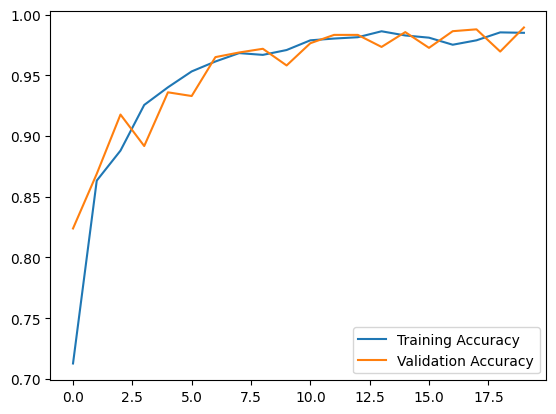

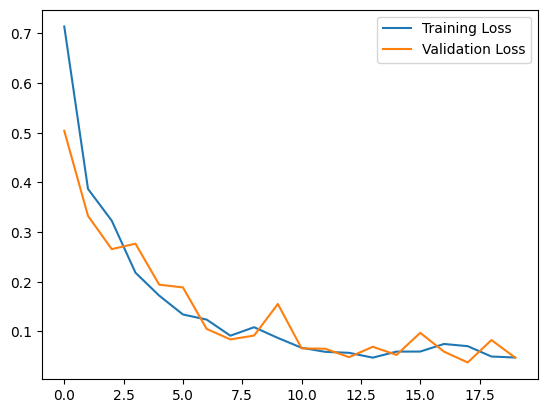

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
Y_pred = model.predict(test_generator)
y_pred = np.argmax(Y_pred, axis=1)


66/66 ━━━━━━━━━━━━━━━━━━━━ 14s 193ms/step


In [ ]:
y_true = test_generator.classes
class_labels = list(test_generator.class_indices.keys())
print("Class labels:", class_labels)
report = classification_report(y_true, y_pred, target_names=class_labels)
print(report)


Class labels: ['glioma', 'meningioma', 'notumor', 'pituitary']
              precision    recall  f1-score   support

      glioma       0.99      0.98      0.98       300
  meningioma       0.97      0.99      0.98       306
     notumor       1.00      1.00      1.00       405
   pituitary       0.99      0.99      0.99       300

    accuracy                           0.99      1311
   macro avg       0.99      0.99      0.99      1311
weighted avg       0.99      0.99      0.99      1311



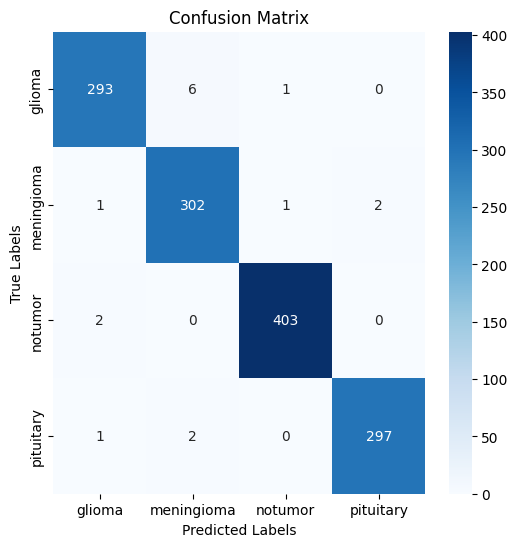

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()


66/66 ━━━━━━━━━━━━━━━━━━━━ 11s 171ms/step


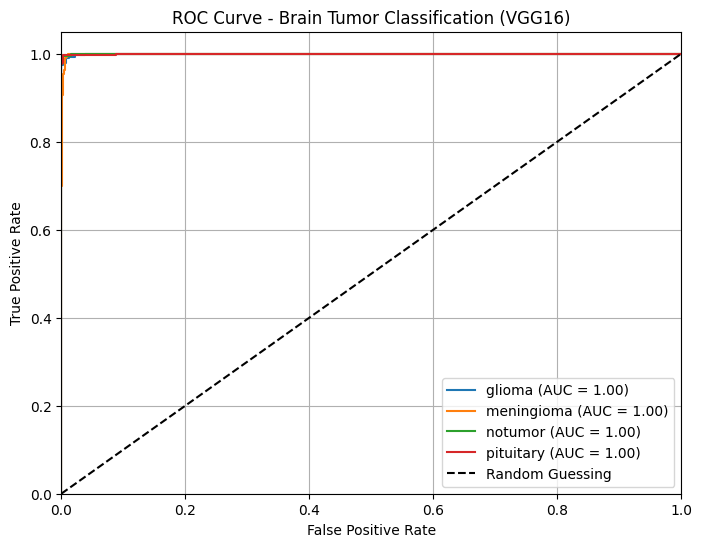

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np
Y_pred = model.predict(test_generator)
y_true = test_generator.classes
class_labels = list(test_generator.class_indices.keys())
y_true_bin = label_binarize(y_true, classes=range(len(class_labels)))
fpr = {}
tpr = {}
roc_auc = {}

for i in range(len(class_labels)):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], Y_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
plt.figure(figsize=(8, 6))
for i in range(len(class_labels)):
    plt.plot(fpr[i], tpr[i],
             label=f'{class_labels[i]} (AUC = {roc_auc[i]:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Brain Tumor Classification (VGG16)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


In [ ]:
model.save('/content/drive/MyDrive/Trained Saved Models/4Types_Brain.h5')


In [ ]:
model.save('/content/drive/MyDrive/Trained Saved Models/4Types_Brain.keras')


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

def detect_and_display(image_path, model):
    img = image.load_img(image_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = img_array / 255.0

    pred = model.predict(img_array)
    predicted_index = np.argmax(pred)
    confidence = np.max(pred) * 100
    class_labels = list(train_generator.class_indices.keys())
    predicted_class = class_labels[predicted_index]
    plt.imshow(image.load_img(image_path))
    plt.axis('off')
    plt.title(f"Predicted: {predicted_class}\nConfidence: {confidence:.2f}%")
    plt.show()
    print(" Predicted Class:", predicted_class)
    print(f" Confidence: {confidence:.2f}%")
    return predicted_class, confidence


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


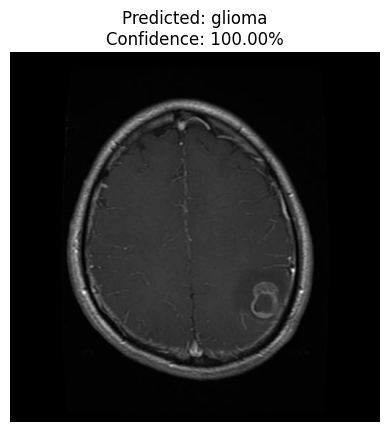

 Predicted Class: glioma
 Confidence: 100.00%


('glioma', np.float32(99.99887))

In [ ]:
image_path='/content/drive/MyDrive/Data for Models/Brain_Tumor/Testing/glioma/Te-gl_0055.jpg'
detect_and_display(image_path, model)